In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import timm
import os
import sys
import gc
import matplotlib.pyplot as plt

# Set absolute paths
PROJECT_ROOT = r'd:\Projects\ML_Algorithms\batchsize'
IMAGE_PATH = r'E:\covidx'
TRAIN_CSV = os.path.join(IMAGE_PATH, 'covidx_merged.csv')

# Add project root and functions to path
if PROJECT_ROOT not in sys.path: sys.path.append(PROJECT_ROOT)
functions_path = os.path.join(PROJECT_ROOT, "functions")
if functions_path not in sys.path: sys.path.append(functions_path)

from dataset import COVIDCXNetDataset
from train import train
from evaluation import plot_results


from batch_size_experiment import run_batch_size_experiments
from visualize_results import visualize_batch_size_results
from find_max_batch import find_max_batch_size
from sample_experiment import run_sample_experiment

c:\Users\Furkan\Miniconda3\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
batch_sizes = [8, 16, 32, 64, 128, 211, 256, 512, 1024, 2048, 4096, 8192]
num_epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

ROOT_DATA_DIR = os.path.dirname(IMAGE_PATH) # E:\\
train_ds = COVIDCXNetDataset(TRAIN_CSV, ROOT_DATA_DIR, transform=transform, split='train')
val_ds = COVIDCXNetDataset(TRAIN_CSV, ROOT_DATA_DIR, transform=transform, split='val')


Using device: cuda
Original samples: 67863
Valid AP/PA samples: 53691
Loaded 53691 samples for split 'train'
Class distribution: PA=20388, AP=33303
Original samples: 8473
Valid AP/PA samples: 4186
Loaded 4186 samples for split 'val'
Class distribution: PA=1275, AP=2911


### RESNET-18

In [4]:
find_max_batch_size(device = device,model_name='resnet18')


Searching for maximum Batch Size in range [8, 4096] for model 'resnet18'...

Testing Batch Size: 2052...
OOM ❌

Testing Batch Size: 1029...
SUCCESS | Allocated: 792.96 MB | Reserved: 20998.00 MB | Peak: 22148.81 MB

Testing Batch Size: 1540...
OOM ❌

Testing Batch Size: 1284...
OOM ❌

Testing Batch Size: 1156...
OOM ❌

Testing Batch Size: 1092...
OOM ❌

Testing Batch Size: 1060...
OOM ❌

Testing Batch Size: 1044...
SUCCESS | Allocated: 802.17 MB | Reserved: 22272.00 MB | Peak: 22478.64 MB

Testing Batch Size: 1052...
OOM ❌

Testing Batch Size: 1048...
SUCCESS | Allocated: 804.51 MB | Reserved: 21346.00 MB | Peak: 22442.03 MB

Testing Batch Size: 1050...
OOM ❌

Testing Batch Size: 1049...
SUCCESS | Allocated: 805.83 MB | Reserved: 22174.00 MB | Peak: 22466.88 MB

>>> Maximum working Batch Size found: 1049 <<<
>>> Recommended Safe Batch Size: 839 <<<


839

In [5]:
run_sample_experiment(image_path=IMAGE_PATH,batch_sizes=batch_sizes,sample_train_size='full',sample_val_size='full',model_name='resnet18',device=device)

Device: cuda
Setting up dataset...
Original samples: 67863
Valid AP/PA samples: 53691
Loaded 53691 samples for split 'train'
Class distribution: PA=20388, AP=33303
Original samples: 8473
Valid AP/PA samples: 4186
Loaded 4186 samples for split 'val'
Class distribution: PA=1275, AP=2911
Sample Train Size: 53691
Sample Val Size: 4186

--- Testing Batch Size: 8 ---


Success! Max Memory: 353.13 MB

--- Testing Batch Size: 16 ---


Success! Max Memory: 701.72 MB

--- Testing Batch Size: 32 ---


Success! Max Memory: 1042.74 MB

--- Testing Batch Size: 64 ---


Success! Max Memory: 1738.68 MB

--- Testing Batch Size: 128 ---


...

Success! Max Memory: 22346.63 MB

--- Testing Batch Size: 2048 ---


OOM Error for Batch Size 2048

--- Testing Batch Size: 4096 ---


OOM Error for Batch Size 4096

--- Testing Batch Size: 8192 ---


OOM Error for Batch Size 8192

--- Final Results ---
Batch Size 8: Success (Mem: 353.13 MB)
Batch Size 16: Success (Mem: 701.72 MB)
Batch Size 32: Success (Mem: 1042.74 MB)
Batch Size 64: Success (Mem: 1738.68 MB)
Batch Size 128: Success (Mem: 3107.63 MB)
Batch Size 211: Success (Mem: 4922.74 MB)
Batch Size 256: Success (Mem: 5932.48 MB)
Batch Size 512: Success (Mem: 11374.57 MB)
Batch Size 1024: Success (Mem: 22346.63 MB)
Batch Size 2048: OOM
Batch Size 4096: OOM
Batch Size 8192: OOM


{8: 'Success (Mem: 353.13 MB)',
 16: 'Success (Mem: 701.72 MB)',
 32: 'Success (Mem: 1042.74 MB)',
 64: 'Success (Mem: 1738.68 MB)',
 128: 'Success (Mem: 3107.63 MB)',
 211: 'Success (Mem: 4922.74 MB)',
 256: 'Success (Mem: 5932.48 MB)',
 512: 'Success (Mem: 11374.57 MB)',
 1024: 'Success (Mem: 22346.63 MB)',
 2048: 'OOM',
 4096: 'OOM',
 8192: 'OOM'}

In [3]:
run_sample_experiment(
    image_path=IMAGE_PATH,
    batch_sizes=batch_sizes,
    sample_train_size=0.5, # 50% of the training data
    sample_val_size=0.5,   # 50% of the validation data
    model_name='resnet18',
    device=device
)

Device: cuda
Setting up dataset...
Original samples: 67863
Valid AP/PA samples: 53691
Loaded 53691 samples for split 'train'
Class distribution: PA=20388, AP=33303
Original samples: 8473
Valid AP/PA samples: 4186
Loaded 4186 samples for split 'val'
Class distribution: PA=1275, AP=2911
Sample Train Size: 26845
Sample Val Size: 2093

--- Testing Batch Size: 8 ---


Success! Max Memory: 354.02 MB

--- Testing Batch Size: 16 ---


Success! Max Memory: 701.10 MB

--- Testing Batch Size: 32 ---


Success! Max Memory: 1049.08 MB

--- Testing Batch Size: 64 ---


Success! Max Memory: 1732.36 MB

--- Testing Batch Size: 128 ---


...

Success! Max Memory: 22321.25 MB

--- Testing Batch Size: 2048 ---


OOM Error for Batch Size 2048

--- Testing Batch Size: 4096 ---


OOM Error for Batch Size 4096

--- Testing Batch Size: 8192 ---


OOM Error for Batch Size 8192

--- Final Results ---
Batch Size 8: Success (Mem: 354.02 MB)
Batch Size 16: Success (Mem: 701.10 MB)
Batch Size 32: Success (Mem: 1049.08 MB)
Batch Size 64: Success (Mem: 1732.36 MB)
Batch Size 128: Success (Mem: 3119.69 MB)
Batch Size 211: Success (Mem: 4899.05 MB)
Batch Size 256: Success (Mem: 5943.87 MB)
Batch Size 512: Success (Mem: 11349.03 MB)
Batch Size 1024: Success (Mem: 22321.25 MB)
Batch Size 2048: OOM
Batch Size 4096: OOM
Batch Size 8192: OOM


{8: 'Success (Mem: 354.02 MB)',
 16: 'Success (Mem: 701.10 MB)',
 32: 'Success (Mem: 1049.08 MB)',
 64: 'Success (Mem: 1732.36 MB)',
 128: 'Success (Mem: 3119.69 MB)',
 211: 'Success (Mem: 4899.05 MB)',
 256: 'Success (Mem: 5943.87 MB)',
 512: 'Success (Mem: 11349.03 MB)',
 1024: 'Success (Mem: 22321.25 MB)',
 2048: 'OOM',
 4096: 'OOM',
 8192: 'OOM'}

In [ ]:
results = run_batch_size_experiments(batch_sizes=batch_sizes, num_epochs=5, project_root=PROJECT_ROOT, model_name='resnet18', train_ds=train_ds, val_ds=val_ds)

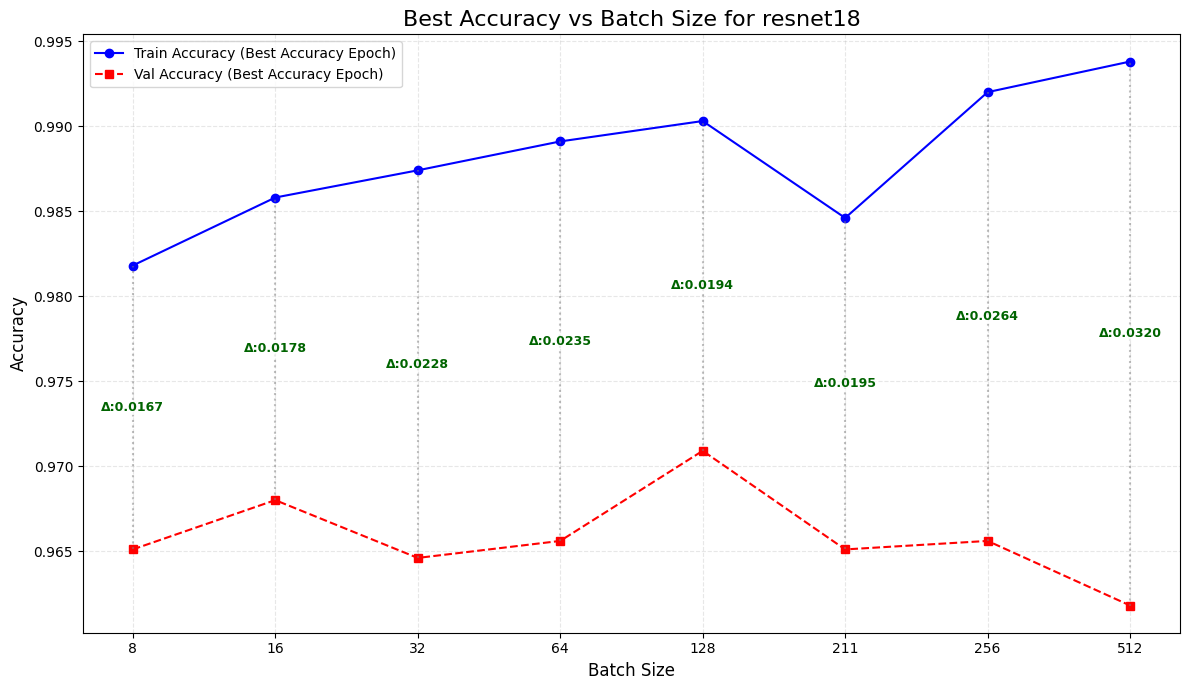


--- Detailed Results (Corrected Diff & Accuracy-Based Best Highlights) ---


Batch Size,Epoch,Train Acc,Val Acc,Diff,Is Best
8,1,0.9570,0.9596,-0.0026,False
8,2,0.9765,0.9601,0.0164,False
8,3,0.9818,0.9651,0.0167,True
8,4,0.9852,0.9589,0.0263,False
16,1,0.9604,0.9623,-0.0019,False
16,2,0.9783,0.9646,0.0137,False
16,3,0.9827,0.9668,0.0159,False
16,4,0.9858,0.9680,0.0178,True
16,5,0.9889,0.9680,0.0209,True
32,1,0.9615,0.9634,-0.0019,False


In [4]:
visualize_batch_size_results(PROJECT_ROOT,model_name='resnet18')

### RESNET-34

In [6]:
find_max_batch_size(device = device,model_name='resnet34')


Searching for maximum Batch Size in range [8, 4096] for model 'resnet34'...

Testing Batch Size: 2052...
OOM ❌

Testing Batch Size: 1029...
OOM ❌

Testing Batch Size: 518...
SUCCESS | Allocated: 657.17 MB | Reserved: 11066.00 MB | Peak: 16196.55 MB

Testing Batch Size: 773...
OOM ❌

Testing Batch Size: 645...
SUCCESS | Allocated: 727.22 MB | Reserved: 21432.00 MB | Peak: 20132.90 MB

Testing Batch Size: 709...
SUCCESS | Allocated: 762.51 MB | Reserved: 14148.00 MB | Peak: 22122.93 MB

Testing Batch Size: 741...
OOM ❌

Testing Batch Size: 725...
OOM ❌

Testing Batch Size: 717...
SUCCESS | Allocated: 769.54 MB | Reserved: 7022.00 MB | Peak: 22279.13 MB

Testing Batch Size: 721...
OOM ❌

Testing Batch Size: 719...
SUCCESS | Allocated: 767.29 MB | Reserved: 7040.00 MB | Peak: 22347.47 MB

Testing Batch Size: 720...
SUCCESS | Allocated: 769.74 MB | Reserved: 15136.00 MB | Peak: 22380.45 MB

>>> Maximum working Batch Size found: 720 <<<
>>> Recommended Safe Batch Size: 576 <<<


576

In [7]:
run_sample_experiment(image_path=IMAGE_PATH,batch_sizes=batch_sizes,sample_train_size='full',sample_val_size='full',model_name='resnet34',device=device)

Device: cuda
Setting up dataset...
Original samples: 67863
Valid AP/PA samples: 53691
Loaded 53691 samples for split 'train'
Class distribution: PA=20388, AP=33303
Original samples: 8473
Valid AP/PA samples: 4186
Loaded 4186 samples for split 'val'
Class distribution: PA=1275, AP=2911
Sample Train Size: 53691
Sample Val Size: 4186

--- Testing Batch Size: 8 ---


Success! Max Memory: 565.45 MB

--- Testing Batch Size: 16 ---


Success! Max Memory: 1141.60 MB

--- Testing Batch Size: 32 ---


Success! Max Memory: 1632.94 MB

--- Testing Batch Size: 64 ---


Success! Max Memory: 2633.56 MB

--- Testing Batch Size: 128 ---


...

OOM Error for Batch Size 1024

--- Testing Batch Size: 2048 ---


OOM Error for Batch Size 2048

--- Testing Batch Size: 4096 ---


OOM Error for Batch Size 4096

--- Testing Batch Size: 8192 ---


OOM Error for Batch Size 8192

--- Final Results ---
Batch Size 8: Success (Mem: 565.45 MB)
Batch Size 16: Success (Mem: 1141.60 MB)
Batch Size 32: Success (Mem: 1632.94 MB)
Batch Size 64: Success (Mem: 2633.56 MB)
Batch Size 128: Success (Mem: 4622.00 MB)
Batch Size 211: Success (Mem: 7220.80 MB)
Batch Size 256: Success (Mem: 8669.66 MB)
Batch Size 512: Success (Mem: 16557.59 MB)
Batch Size 1024: OOM
Batch Size 2048: OOM
Batch Size 4096: OOM
Batch Size 8192: OOM


{8: 'Success (Mem: 565.45 MB)',
 16: 'Success (Mem: 1141.60 MB)',
 32: 'Success (Mem: 1632.94 MB)',
 64: 'Success (Mem: 2633.56 MB)',
 128: 'Success (Mem: 4622.00 MB)',
 211: 'Success (Mem: 7220.80 MB)',
 256: 'Success (Mem: 8669.66 MB)',
 512: 'Success (Mem: 16557.59 MB)',
 1024: 'OOM',
 2048: 'OOM',
 4096: 'OOM',
 8192: 'OOM'}

In [ ]:
run_sample_experiment(
    image_path=IMAGE_PATH,
    batch_sizes=batch_sizes,
    sample_train_size=0.5, # 50% of the training data
    sample_val_size=0.5,   # 50% of the validation data
    model_name='resnet34',
    device=device
)

In [ ]:
results = run_batch_size_experiments(batch_sizes=batch_sizes, num_epochs=5, project_root=PROJECT_ROOT, model_name='resnet34', train_ds=train_ds, val_ds=val_ds)

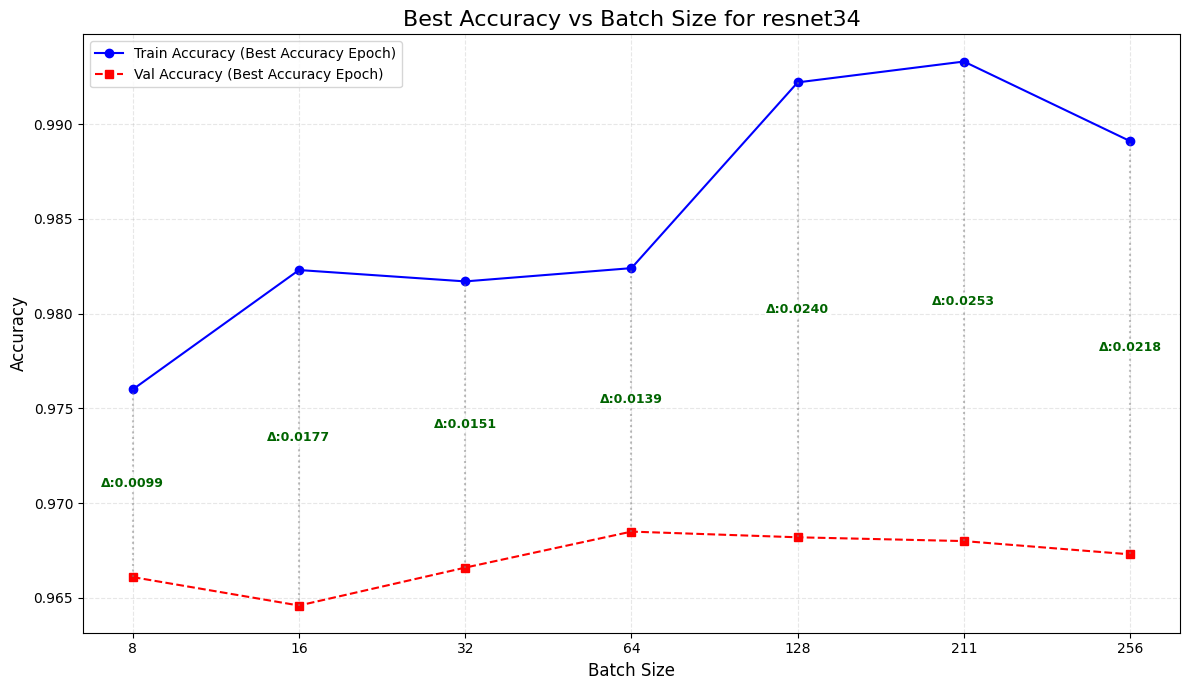


--- Detailed Results (Corrected Diff & Accuracy-Based Best Highlights) ---


Batch Size,Epoch,Train Acc,Val Acc,Diff,Is Best
8,1,0.9587,0.9565,0.0022,False
8,2,0.9760,0.9661,0.0099,True
8,3,0.9811,0.9577,0.0234,False
8,4,0.9840,0.9623,0.0217,False
8,5,0.9872,0.9639,0.0233,False
16,1,0.9621,0.9582,0.0039,False
16,2,0.9782,0.9594,0.0188,False
16,3,0.9823,0.9646,0.0177,True
16,4,0.9857,0.9572,0.0285,False
16,5,0.9882,0.9563,0.0319,False


In [5]:
visualize_batch_size_results(PROJECT_ROOT,model_name='resnet34')

### RESNET-50

In [3]:
find_max_batch_size(device = device,model_name='resnet50')


Searching for maximum Batch Size in range [8, 4096] for model 'resnet50'...

Testing Batch Size: 2052...
OOM ❌

Testing Batch Size: 1029...
OOM ❌

Testing Batch Size: 518...
OOM ❌

Testing Batch Size: 262...
SUCCESS | Allocated: 563.96 MB | Reserved: 15542.00 MB | Peak: 21796.94 MB

Testing Batch Size: 390...
OOM ❌

Testing Batch Size: 326...
OOM ❌

Testing Batch Size: 294...
OOM ❌

Testing Batch Size: 278...
OOM ❌

Testing Batch Size: 270...
SUCCESS | Allocated: 566.47 MB | Reserved: 20790.00 MB | Peak: 22464.14 MB

Testing Batch Size: 274...
OOM ❌

Testing Batch Size: 272...
OOM ❌

Testing Batch Size: 271...
OOM ❌

>>> Maximum working Batch Size found: 270 <<<
>>> Recommended Safe Batch Size: 216 <<<


216

In [5]:
run_sample_experiment(image_path=IMAGE_PATH,batch_sizes=batch_sizes,sample_train_size='full',sample_val_size='full',model_name='resnet50',device=device)

Device: cuda
Setting up dataset...
Original samples: 67863
Valid AP/PA samples: 53691
Loaded 53691 samples for split 'train'
Class distribution: PA=20388, AP=33303
Sample Train Size: 53691
Sample Val Size: 0

--- Testing Batch Size: 8 ---


Success! Max Memory: 1005.83 MB

--- Testing Batch Size: 16 ---


Success! Max Memory: 2026.67 MB

--- Testing Batch Size: 32 ---


Success! Max Memory: 3333.77 MB

--- Testing Batch Size: 64 ---


Success! Max Memory: 5991.22 MB

--- Testing Batch Size: 128 ---


...

OOM Error for Batch Size 1024

--- Testing Batch Size: 2048 ---


OOM Error for Batch Size 2048

--- Testing Batch Size: 4096 ---


OOM Error for Batch Size 4096

--- Testing Batch Size: 8192 ---


OOM Error for Batch Size 8192

--- Final Results ---
Batch Size 8: Success (Mem: 1005.83 MB)
Batch Size 16: Success (Mem: 2026.67 MB)
Batch Size 32: Success (Mem: 3333.77 MB)
Batch Size 64: Success (Mem: 5991.22 MB)
Batch Size 128: Success (Mem: 11292.47 MB)
Batch Size 211: Success (Mem: 18154.05 MB)
Batch Size 256: Success (Mem: 21880.43 MB)
Batch Size 512: OOM
Batch Size 1024: OOM
Batch Size 2048: OOM
Batch Size 4096: OOM
Batch Size 8192: OOM


{8: 'Success (Mem: 1005.83 MB)',
 16: 'Success (Mem: 2026.67 MB)',
 32: 'Success (Mem: 3333.77 MB)',
 64: 'Success (Mem: 5991.22 MB)',
 128: 'Success (Mem: 11292.47 MB)',
 211: 'Success (Mem: 18154.05 MB)',
 256: 'Success (Mem: 21880.43 MB)',
 512: 'OOM',
 1024: 'OOM',
 2048: 'OOM',
 4096: 'OOM',
 8192: 'OOM'}

In [4]:
run_sample_experiment(
    image_path=IMAGE_PATH,
    batch_sizes=batch_sizes,
    sample_train_size=0.5, # 50% of the training data
    sample_val_size=0.5,   # 50% of the validation data
    model_name='resnet50',
    device=device
)

Device: cuda
Setting up dataset...
Original samples: 67863
Valid AP/PA samples: 53691
Loaded 53691 samples for split 'train'
Class distribution: PA=20388, AP=33303
Original samples: 8473
Valid AP/PA samples: 4186
Loaded 4186 samples for split 'val'
Class distribution: PA=1275, AP=2911
Sample Train Size: 26845
Sample Val Size: 2093

--- Testing Batch Size: 8 ---


Success! Max Memory: 1004.54 MB

--- Testing Batch Size: 16 ---


Success! Max Memory: 2027.31 MB

--- Testing Batch Size: 32 ---


Success! Max Memory: 3339.70 MB

--- Testing Batch Size: 64 ---


Success! Max Memory: 5988.86 MB

--- Testing Batch Size: 128 ---


...

OOM Error for Batch Size 1024

--- Testing Batch Size: 2048 ---


OOM Error for Batch Size 2048

--- Testing Batch Size: 4096 ---


OOM Error for Batch Size 4096

--- Testing Batch Size: 8192 ---


OOM Error for Batch Size 8192

--- Final Results ---
Batch Size 8: Success (Mem: 1004.54 MB)
Batch Size 16: Success (Mem: 2027.31 MB)
Batch Size 32: Success (Mem: 3339.70 MB)
Batch Size 64: Success (Mem: 5988.86 MB)
Batch Size 128: Success (Mem: 11288.27 MB)
Batch Size 211: Success (Mem: 18159.35 MB)
Batch Size 256: Success (Mem: 21943.18 MB)
Batch Size 512: OOM
Batch Size 1024: OOM
Batch Size 2048: OOM
Batch Size 4096: OOM
Batch Size 8192: OOM


{8: 'Success (Mem: 1004.54 MB)',
 16: 'Success (Mem: 2027.31 MB)',
 32: 'Success (Mem: 3339.70 MB)',
 64: 'Success (Mem: 5988.86 MB)',
 128: 'Success (Mem: 11288.27 MB)',
 211: 'Success (Mem: 18159.35 MB)',
 256: 'Success (Mem: 21943.18 MB)',
 512: 'OOM',
 1024: 'OOM',
 2048: 'OOM',
 4096: 'OOM',
 8192: 'OOM'}

In [ ]:
results = run_batch_size_experiments(batch_sizes=batch_sizes, num_epochs=5, project_root=PROJECT_ROOT, model_name='resnet50', train_ds=train_ds, val_ds=val_ds)

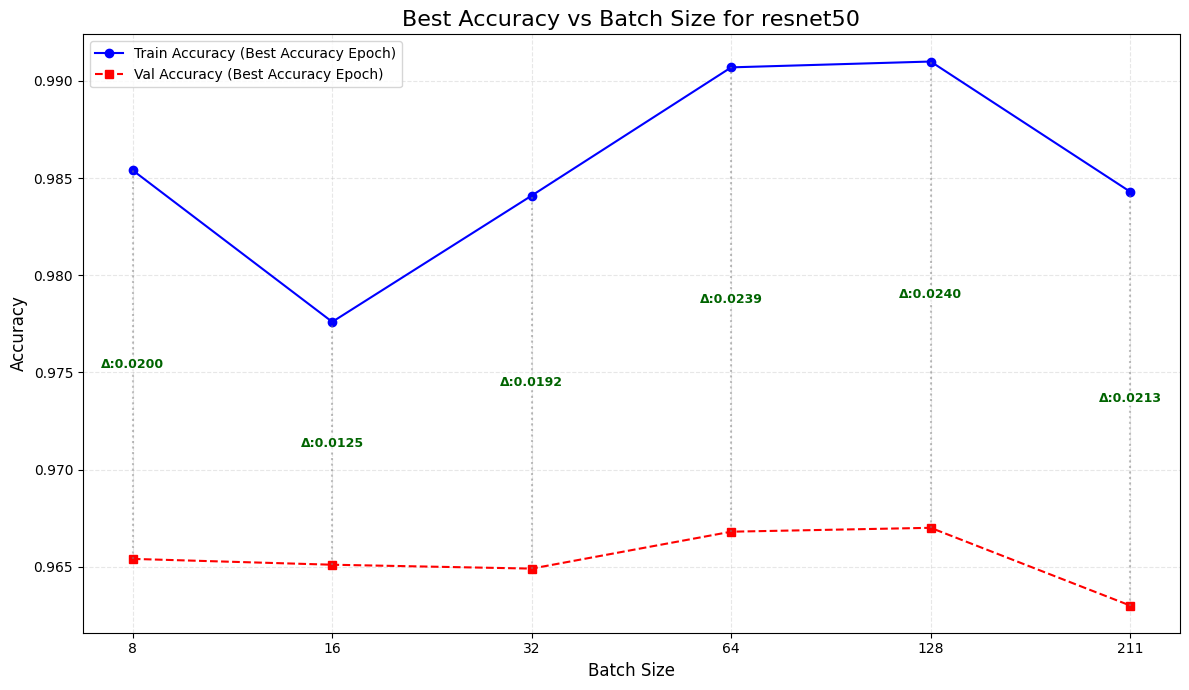


--- Detailed Results (Corrected Diff & Accuracy-Based Best Highlights) ---


Batch Size,Epoch,Train Acc,Val Acc,Diff,Is Best
8,1,0.9593,0.9546,0.0047,False
8,2,0.9755,0.9484,0.0271,False
8,3,0.9791,0.9632,0.0159,False
8,4,0.9835,0.9615,0.0220,False
8,5,0.9854,0.9654,0.0200,True
16,1,0.9631,0.9539,0.0092,False
16,2,0.9776,0.9651,0.0125,True
16,3,0.9824,0.9620,0.0204,False
16,4,0.9846,0.9644,0.0202,False
16,5,0.9880,0.9608,0.0272,False


In [9]:
visualize_batch_size_results(PROJECT_ROOT,model_name='resnet50')